In [1]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import seaborn as sns

In [4]:
def load_multi_wave_file(filename):
    """
    Yields (times, waves) tuples. 
    Detects a new matrix when the 'time' value decreases (reset).
    """
    current_times, current_waves = [], []
    last_t = -1

    with open(filename) as f:
        next(f)  # skip the header
        for line in f:
            parts = line.rstrip().split("\t")
            if len(parts) < 2: continue
            
            t = int(parts[0])
            wave_data = np.fromstring(parts[1], sep=",", dtype=int)

            if t < last_t and current_times:
                yield np.array(current_times), np.array(current_waves)
                current_times, current_waves = [], []
            
            current_times.append(t)
            current_waves.append(wave_data)
            last_t = t
            
        if current_times:
            yield np.array(current_times), np.array(current_waves)


def compute_density_matrix(wave_matrix, max_load):
    """Computes density matrix with a fixed max_load to ensure consistent shape."""
    T = wave_matrix.shape[0]
    density = np.zeros((T, max_load + 1), dtype=int)
    for i in range(T):
        density[i] = np.bincount(wave_matrix[i], minlength=max_load + 1)
    return density


def summarize_waves_single_heatmap(
    input_file, output_folder, pop_size=5000, sel_coef=0.001
):

    # "poster" is the largest preset context in Seaborn (larger than "talk")
    sns.set_context("paper")
    sns.set_style("ticks")

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
    })

    fig_width = 426.79134 * 0.48 / 72.27
    fig_height = fig_width / 1.518

    file_path = Path(input_file)
    os.makedirs(output_folder, exist_ok=True)

    match = re.search(r"(N\d+.*)", file_path.stem)
    out_name = (
        f"wave_summary_{match.group(1)}.png"
        if match
        else f"wave_summary_{file_path.stem}.png"
    )
    output_path = Path(output_folder) / out_name

    all_chunks = list(load_multi_wave_file(file_path))
    if not all_chunks:
        print("No data found in file.")
        return

    global_max_load = max(wave_matrix.max() for _, wave_matrix in all_chunks)

    full_density_list = []
    full_times_list = []

    for times, wave_matrix in all_chunks:
        density = compute_density_matrix(wave_matrix, global_max_load)
        full_density_list.append(density)
        full_times_list.append(times)

    combined_density = np.vstack(full_density_list)
    combined_times = np.concatenate(full_times_list)

    # --- PLOTTING CHANGES START HERE ---
    plt.figure(figsize=(fig_width, fig_height))

    cmap = plt.cm.inferno
    cmap.set_under("white")

    time_indices = np.arange(combined_density.shape[0])

    im = plt.imshow(
        combined_density.T,
        aspect="auto",
        origin="lower",
        extent=[time_indices.min(), time_indices.max(), 0, global_max_load],
        norm=LogNorm(vmin=1, vmax=max(2, combined_density.max())),
        cmap=cmap,
    )

    # Increased font sizes for Title and Axes Labels
    plt.title(f"Ns = {pop_size * sel_coef:.0f}", fontsize=10, pad=6)
    plt.xlabel("Time (Generations)", fontsize=10, labelpad=4)
    plt.ylabel("Absolute Mutational Burden", fontsize=10, labelpad=4)

    # Increased font sizes for Tick Labels (numbers on axes)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)

    # Increased font sizes for Colorbar Label and Ticks
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Individuals", fontsize=10, labelpad=6)
    cbar.ax.tick_params(labelsize=9)
    # --- PLOTTING CHANGES END HERE ---

    plt.tight_layout(pad = 0.1)
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.close()
    print(f"Saved single heatmap to {output_path}")

In [5]:
summarize_waves_single_heatmap("tmp/results/wave_N5000_U0.006_s0.0004.out", "tmp/figures", sel_coef=0.0004)

Saved single heatmap to tmp/figures/wave_summary_N5000_U0.006_s0.0004.png


In [6]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import seaborn as sns

def summarize_waves_stationary_heatmap(
    input_file, output_folder, pop_size=5000, sel_coef=0.001
):
    # Upgraded context to "poster" for globally larger text elements
    sns.set_context("paper")
    sns.set_style("ticks")
    
    plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    })
    
    fig_width = 426.79134 * 0.48 / 72.27
    fig_height = fig_width / 1.518

    file_path = Path(input_file)
    os.makedirs(output_folder, exist_ok=True)

    match = re.search(r"(N\d+.*)", file_path.stem)
    suffix = match.group(1) if match else file_path.stem
    out_name = f"wave_summary_stationary_{suffix}.png"
    output_path = Path(output_folder) / out_name

    all_chunks = list(load_multi_wave_file(file_path))
    if not all_chunks:
        print("No data found in file.")
        return

    global_max_load = max(wave_matrix.max() for _, wave_matrix in all_chunks)

    full_density_list = []
    full_waves_list = []

    for times, wave_matrix in all_chunks:
        density = compute_density_matrix(wave_matrix, global_max_load)
        full_density_list.append(density)
        full_waves_list.append(wave_matrix)

    combined_density = np.vstack(full_density_list)
    combined_waves = np.vstack(full_waves_list)
    time_indices = np.arange(combined_density.shape[0])

    mean_burdens = np.mean(combined_waves, axis=1)

    slope, intercept = np.polyfit(time_indices, mean_burdens, 1)
    predicted_means = slope * time_indices + intercept

    y_max = 40
    y_center = 20
    stationary_density = np.zeros((len(time_indices), y_max + 1))

    for t in time_indices:
        pred_mean = int(round(predicted_means[t]))

        for y in range(y_max + 1):
            orig_mutation_load = pred_mean + (y - y_center)
            if 0 <= orig_mutation_load <= global_max_load:
                stationary_density[t, y] = combined_density[t, orig_mutation_load]

    # --- PLOTTING CHANGES START HERE ---
    # Increased figure dimensions slightly to balance large fonts
    plt.figure(figsize=(fig_width, fig_height))
    cmap = plt.cm.inferno
    cmap.set_under("white")

    im = plt.imshow(
        stationary_density.T,
        aspect="auto",
        origin="lower",
        extent=[time_indices.min(), time_indices.max(), 0, y_max],
        norm=LogNorm(vmin=1, vmax=max(2, stationary_density.max())),
        cmap=cmap,
    )

    # Increased font sizes for Title and Axes Labels
    plt.title(f"Normalized Ns = {pop_size * sel_coef:.0f}", fontsize=10, pad=6)
    plt.xlabel("Time (Generations)", fontsize=10, labelpad=4)
    plt.ylabel("Relative Mutational Burden", fontsize=10, labelpad=4)

    # Increased font sizes for Tick Labels
    plt.xticks(fontsize=9)
    plt.yticks(np.arange(0, 41, 10), fontsize=9)

    # Increased font sizes for Colorbar Label and Ticks
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Individuals", fontsize=10, labelpad=6)
    cbar.ax.tick_params(labelsize=9)
    # --- PLOTTING CHANGES END HERE ---

    plt.tight_layout(pad = 0.2)
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.close()
    print(f"Saved stationary heatmap to {output_path}")

In [7]:
summarize_waves_stationary_heatmap("tmp/results/wave_N5000_U0.006_s0.0004.out", "tmp/figures", pop_size=5000, sel_coef=0.0004)

Saved stationary heatmap to tmp/figures/wave_summary_stationary_N5000_U0.006_s0.0004.png


In [19]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def visualize_profile_distribution(input_file, output_folder=None):
    """Reads a simulation CSV/TSV file and plots the mutational profile distribution."""
    # Set context to poster for globally larger, presentation-ready labels
    sns.set_context("poster")
    sns.set_style("ticks")

    file_path = Path(input_file)

    # 1. Read and parse the file manually to handle potential mixed delimiters safely
    profile_data = None
    pop_size = 5000  # Default fallbacks for title if parsing fails
    sel_coef = 0.001

    with open(file_path, "r") as f:
        header = f.readline().strip().split()
        try:
            profile_idx = header.index("profile")
            popsize_idx = header.index("popsize")
            selcoef_idx = header.index("selcoef")
        except ValueError:
            header = re.split(r"\t|,", header[0])
            profile_idx = header.index("profile")
            popsize_idx = header.index("popsize")
            selcoef_idx = header.index("selcoef")

        data_line = f.readline().strip()
        if data_line:
            parts = re.split(r"\t|\s+", data_line)

            pop_size = float(parts[popsize_idx])
            sel_coef = float(parts[selcoef_idx])

            profile_str = parts[profile_idx]
            profile_data = np.fromstring(profile_str, sep=",", dtype=float)

    if profile_data is None:
        print("Error: Could not parse profile data.")
        return

    # 2. Create the distribution indices (bins)
    mutation_bins = np.arange(len(profile_data))

    # 3. Plotting
    # Increased figure dimensions slightly to comfortably fit larger fonts
    plt.figure(figsize=(12, 8))

    # Using plt.bar to represent the discrete frequency histogram
    plt.bar(
        mutation_bins,
        profile_data,
        width=0.85,
        color="#2c3e50",
        edgecolor="black",
        alpha=0.85,
        label="Profile Density",
    )

    plt.title(
        f"Mutational Profile Distribution\nNs = {pop_size * sel_coef:.0f}",
        fontweight="bold",
        fontsize=28,
        pad=15,
    )
    plt.xlabel("Mutational Burden Class", fontsize=25, labelpad=12)
    plt.ylabel("Proportion", fontsize=25, labelpad=12)

    tick_step = 1 if len(mutation_bins) <= 20 else 5
    discrete_ticks = np.arange(0, len(profile_data), tick_step)

    # Increased font sizes for Axis Ticks
    plt.xticks(discrete_ticks, fontsize=22)
    plt.yticks(fontsize=22)
    # --- PLOTTING CHANGES END HERE ---

    plt.xlim(-0.5, len(profile_data) - 0.5)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    sns.despine()
    plt.tight_layout()

    # 4. Save or Show
    if output_folder:
        os.makedirs(output_folder, exist_ok=True)
        output_path = (
            Path(output_folder) / f"profile_histogram_{file_path.stem}.png"
        )
        plt.savefig(output_path, dpi=300)
        plt.close()
        print(f"Profile histogram saved to {output_path}")
    else:
        plt.show()



In [20]:
visualize_profile_distribution("tmp/results/escsim_N5000_U0.006_s0.0004.out", "tmp/figures")

Profile histogram saved to tmp/figures/profile_histogram_escsim_N5000_U0.006_s0.0004.png


In [3]:
from pathlib import Path

import warnings
import os

from scipy.linalg import expm
from scipy import interpolate, integrate
from math import comb

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def read_params(df):
    """
    Reads the parameters from the results file and converts them to variables.
    
    df: DataFrame containing the results from the forward-simulation.

    Returns:
    pop_size: Population size.
    mut_rate: Mutation rate.
    sel_coef: Selection coefficient.
    v: Velocity of the wave.
    """
    pop_size = int(df["popsize"].iloc[0])
    mut_rate = df["mutrate"].iloc[0]
    sel_coef = df["selcoef"].iloc[0]
    return pop_size, mut_rate, sel_coef

def get_mean_velocity(df):
    """
    Calculates the mean velocity from a
    DataFrame containing simulation results.
    """
    if "velocity" not in df.columns:
        click.echo("[WARNING] 'velocity' column not found in results.")
        return 0.0
    
    # Calculate the mean of all rows in the velocity column
    mean_v = df["velocity"].mean()
    
    # Apply your existing bounds checks to the final mean
    if mean_v > 1:
        mean_v = 1.0
    elif mean_v < 0:
        mean_v = 0.0
        
    return mean_v

def get_mean_profile(df):
    """
    Calculates the mean profile from 
    a DataFrame containing simulation results.
    """

    all_profiles = []
    max_len = 0
    
    # First pass: collect and find the longest profile
    for profile_str in df["profile"]:
        p = np.fromstring(profile_str, sep=",", dtype=float)
        all_profiles.append(p)
        if len(p) > max_len:
            max_len = len(p)
            
    if not all_profiles:
        return None
        
    # Second pass: pad ONLY the right side (the end) to match max_len
    padded_profiles = [
        np.pad(p, (0, max_len - len(p)), mode='constant', constant_values=0.0) 
        for p in all_profiles
    ]
    
    # Compute mean across the rows
    return np.mean(padded_profiles, axis=0)

def create_transition_matrix(mut_burden_profile, mut_rate, velocity):
    """ 
    Creates the transition matrix for the backward simulation. 
    mut_burden_profile: List of mutation burden profiles for each time point. 
    mut_rate: Mutation rate. 
    velocity: Velocity of the wave.
    
    Returns: transition_matrix: A 2D numpy array representing the transition probabilities
                                between states.
    """

    # Get the number of states from the length of the mutational burden profile
    num_states = len(mut_burden_profile)

    # Initialize the transition rate matrix with zeros
    transition_rate_matrix = np.zeros((num_states, num_states), dtype=np.float64)

    # calculate off-diagonal rates
    for k in range(num_states):

        # skip states with zero mutational burden to avoid division by zero
        if mut_burden_profile[k] == 0:
            continue

        # fill in the matrix with backward transition rates
        if k > 0:
            transition_rate_matrix[k, k-1] = (mut_rate * mut_burden_profile[k-1] /
                                              mut_burden_profile[k])

        # fill in the matrix with forward transition rates
        if k < num_states - 1:
            transition_rate_matrix[k, k+1] = (mut_rate * velocity *
                                              mut_burden_profile[k+1] /
                                              mut_burden_profile[k])

    # fill diagonals by enforcing row sums to zero
    row_sums = transition_rate_matrix.sum(axis=1)
    transition_rate_matrix[np.arange(num_states), np.arange(num_states)] -= row_sums

    return transition_rate_matrix

def calc_next_lineage_dist(mut_burden_profile, t, transition_rate_matrix):
    """
    Retrieves the mutational burden profile at a specific time point.
    
    mut_burden_profile: List of mutation burden profiles for each time point.
    t: The time point for which to retrieve the mutational burden profile.
    transition_rate_matrix: The transition rate matrix defining transition rates
                            between states.

    Returns:
    The dot product of the initial mutational burden profile
    and the matrix exponential of the transition rate matrix multiplied by time t,
    which gives the lineage distribution at time t.
    """

    # return the lineage distribution at time t
    # as the dot product of the initial mutational burden profile
    # and the matrix exponential of the transition rate matrix multiplied by time t
    return np.dot(mut_burden_profile, expm(transition_rate_matrix*t))

def visualize_lineage_at_time(input_file, t, output_folder=None):
    """Calculates and plots the backward lineage distribution for a single user-specified time 't'."""
    # Set presentation-ready theme context
    sns.set_context("poster")
    sns.set_style("ticks")

    # 1. Load data and calculate parameters using your defined functions
    df = pd.read_csv(input_file, sep="\t")
    pop_size, mut_rate, sel_coef = read_params(df)
    velocity = get_mean_velocity(df)
    mean_profile = get_mean_profile(df)

    if mean_profile is None:
        print("Error: Could not calculate mean profile.")
        return

    # 2. Build the transition rate matrix using your function
    transition_matrix = create_transition_matrix(
        mean_profile, mut_rate, velocity
    )

    # 3. Calculate distribution exactly at time t
    dist_at_t = calc_next_lineage_dist(mean_profile, t, transition_matrix)
    mutation_classes = np.arange(len(mean_profile))

    # 4. Plotting
    plt.figure(figsize=(12, 8))

    # Choose a color dynamically based on whether it's initial, mid, or deep history
    plot_color = (
        "#2c3e50" if t == 0 else ("#e74c3c" if t < 1000 else "#8e44ad")
    )

    plt.bar(
        mutation_classes,
        dist_at_t,
        width=0.85,
        color=plot_color,
        edgecolor="black",
        alpha=0.85,
    )

    # --- TEXT AND LABEL CUSTOMIZATION ---
    # Put the specific time directly in the main title
    plt.title(
        f"Lineage Distribution at t = {t} Generations\nNs = {pop_size * sel_coef:.0f}",
        fontweight="bold",
        fontsize=30,
        pad=15,
    )

    plt.xlabel("Mutational Burden Class", fontsize=30, labelpad=12)
    plt.ylabel("Lineage Density", fontsize=30, labelpad=12)

    # Limits and grid details
    plt.xlim(-0.5, len(mean_profile) - 0.5)
    plt.ylim(bottom=0)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    sns.despine()
    plt.tight_layout()

    # 5. Save or Display
    if output_folder:
        os.makedirs(output_folder, exist_ok=True)
        file_path = Path(input_file)
        output_path = (
            Path(output_folder) / f"lineage_t{t}_{file_path.stem}.png"
        )
        plt.savefig(output_path, dpi=300)
        plt.close()
        print(f"Lineage plot for t={t} saved to {output_path}")
    else:
        plt.show()

In [4]:
visualize_lineage_at_time("tmp/results/escsim_N5000_U0.006_s0.0004.out", 0, "tmp/figures")
visualize_lineage_at_time("tmp/results/escsim_N5000_U0.006_s0.0004.out", 100, "tmp/figures")
visualize_lineage_at_time("tmp/results/escsim_N5000_U0.006_s0.0004.out", 1000, "tmp/figures")

Lineage plot for t=0 saved to tmp/figures/lineage_t0_escsim_N5000_U0.006_s0.0004.png
Lineage plot for t=100 saved to tmp/figures/lineage_t100_escsim_N5000_U0.006_s0.0004.png
Lineage plot for t=1000 saved to tmp/figures/lineage_t1000_escsim_N5000_U0.006_s0.0004.png


/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_990/1588112275.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


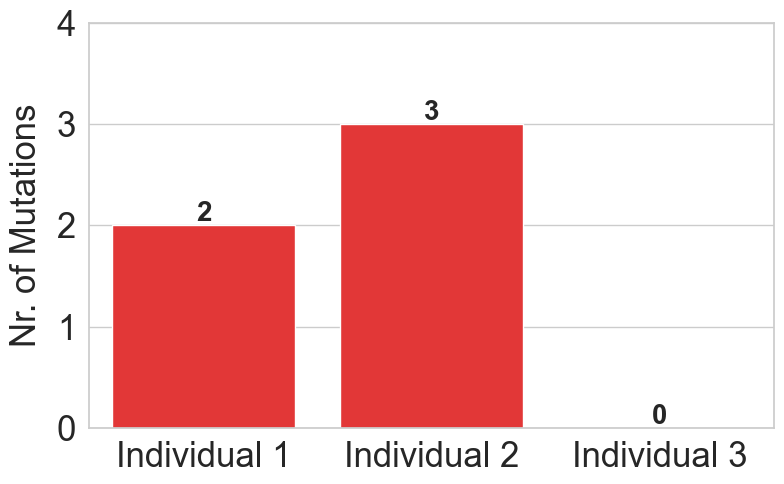

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create the dataset based on the diagram
data = {
    'Individual': ['Individual 1', 'Individual 2', 'Individual 3'],
    'Mutations': [2, 3, 0]
}
df = pd.DataFrame(data)

sns.set_context("poster")  # Set context to poster for larger text

# 2. Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Create the bar plot (using a vibrant red to match your diagram)
ax = sns.barplot(
    x='Individual', 
    y='Mutations', 
    data=df, 
    palette=['#ff1a1a', '#ff1a1a', '#ff1a1a']
)

# 4. Customize labels and title
plt.title('', fontsize=25, fontweight='bold', pad=15)
plt.xticks(fontsize=25)
plt.xlabel('')
plt.ylabel('Nr. of Mutations', fontsize=25, labelpad=10)

# Adjust y-axis to show clean integer steps
plt.yticks(range(0, 5), fontsize=25)

# 5. Add value labels on top of each bar for clarity
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontweight='bold',
        fontsize=20
    )

# Optimize layout and display
plt.tight_layout()
plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_3294/2636547283.py:47: SyntaxWarning: invalid escape sequence '\s'
  label = f"$\sigma = {multiplier}s_{{normal}}$"
/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_3294/2636547283.py:84: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25, top=0.85, wspace=0.38)
/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_3294/2636547283.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.2)


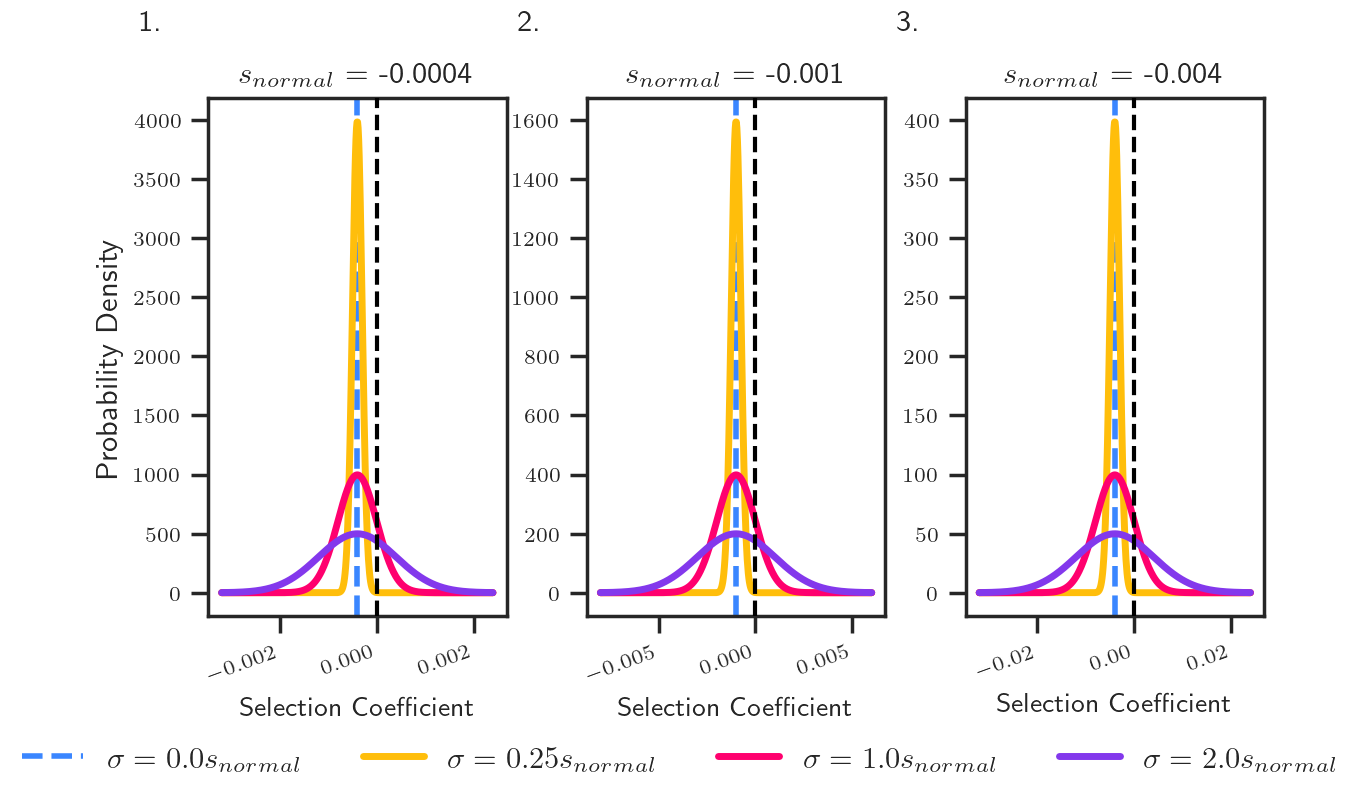

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    })
# Set the style and color-blind friendly palette
sns.set_context("paper")  # Set context to poster for larger text
sns.set_theme(style="ticks")
cb_palette = [
    "#3A86FF",  
    "#FFBE0B",  # 2. Warm Ochre Yellow (Bright Warm Accent)
    "#FF006E",  # 3. Forest Teal (Mid-tone Cool/Green)
    "#8338EC",  # 4. Soft Coral Red (Mid-tone Red/Pink)
    "#FB5607",  # 5. Frost Sky Blue (Light Highlight)
]

fig_width = 426.79134  / 72.27
fig_height = fig_width / 1.618

# Define the means for the 3 columns and the standard deviation multipliers
means = [-0.0004, -0.001, -0.004]
sd_multipliers = [0.0, 0.25, 1.0, 2.0]

subfig_labels = ["1.", "2.", "3."]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=False)

# Loop through each mean (each subplot)
for i, mean in enumerate(means):
    ax = axes[i]
    
    # Define a broad x range centered around the current mean for plotting
    # Using the largest SD (1.0 * mean) to capture the widest distribution
    abs_mean = abs(mean)
    max_sd = max(sd_multipliers) * abs_mean
    x = np.linspace(mean - 3.5 * max_sd, mean + 3.5 * max_sd, 500)
    
    # Plot each standard deviation
    for j, multiplier in enumerate(sd_multipliers):
        sd = multiplier * abs_mean
        label = f"$\sigma = {multiplier}s_{{normal}}$"
        
        if sd == 0:
            # SD = 0 is mathematically a vertical line (Dirac delta)
            ax.axvline(x=mean, color=cb_palette[j], linestyle="--", linewidth=2, label=label)
        else:
            # Calculate the normal PDF
            y = stats.norm.pdf(x, mean, sd)
            ax.plot(x, y, color=cb_palette[j], linewidth=2.5, label=label)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, zorder=3)
            
    # Subplot styling
    ax.set_title(axis_title:=f"$s_{{normal}}$ = {mean}", fontsize=11, pad=6)
    ax.set_xlabel("Selection Coefficient", fontsize=10, labelpad=4)
    ax.tick_params(axis='both', which='major', labelsize=7.5)

    # ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))

    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    ax.text(-0.15, 1.12, subfig_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='right')
    if i == 0:
        ax.set_ylabel("Probability Density", fontsize=11, labelpad=4)

# Collect handles and labels to remove duplicates for a single horizontal legend
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
by_label = dict(zip(labels, handles))

# Compact horizontal legend resting neatly beneath the three columns
# Changed to 3 columns to span nicely across the golden-ratio aspect height
fig.legend(by_label.values(), by_label.keys(), loc='lower center', 
           bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=11, frameon=False)

plt.subplots_adjust(bottom=0.25, top=0.85, wspace=0.38)

plt.tight_layout(pad=0.2)
fig.savefig("tmp/figures/selection_coefficient_distributions.jpg", dpi=600, bbox_inches="tight")
plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_3294/163236172.py:52: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('\% Beneficial Mutations', fontsize=10)
/var/folders/p6/p4dbkljj531g8sp6m3smqc_w0000gq/T/ipykernel_3294/163236172.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.1)


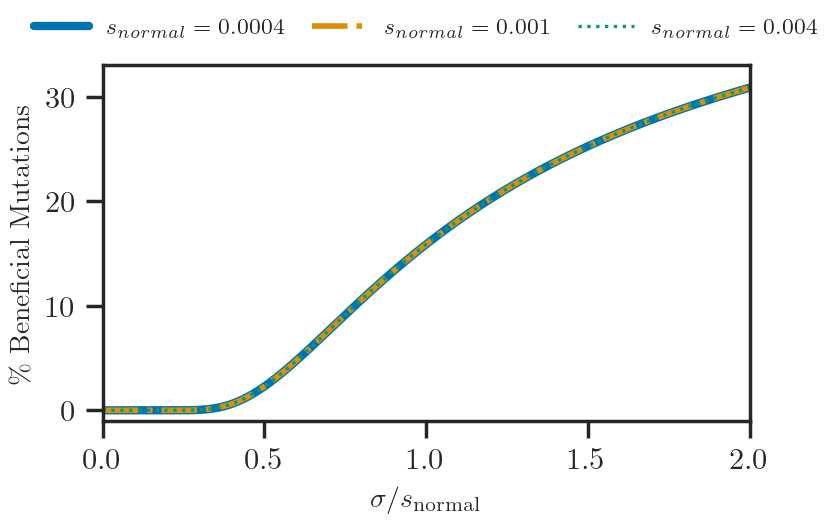

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set Seaborn theme and colorblind palette
sns.set_context("paper")
sns.set_theme(style="ticks")
palette = sns.color_palette("colorblind", 3)

plt.rcParams.update({
    "text.usetex": True,
    "mathtext.fontset": "cm",        
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig_width = 426.79134 / 72.27 * 0.7
fig_height = fig_width / 1.618

# Define negative selection coefficients (s)
selection_coefficients = [-0.0004, -0.001, -0.004]

# Define range for Ratio (sigma / |s|) from 0 to 2
ratios = np.linspace(0.0001, 2.0, 500)

# Line styles to keep all 3 overlapping lines distinguishable
linestyles = ['-', '-.', ':']
linewidths = [3.0, 2.0, 1.2]  # Adjusted slightly for compact figure dimensions

# Initialize plot
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i, s in enumerate(selection_coefficients):
    # Calculate corresponding standard deviations: sigma = ratio * |s|
    sigma_values = ratios * abs(s)
    
    # Calculate % beneficial mutations: P(X > 0)
    pct_beneficial = (1 - norm.cdf(0, loc=s, scale=sigma_values)) * 100
    
    ax.plot(
        ratios, 
        pct_beneficial, 
        label=f'$s_{{normal}} = {np.abs(s)}$', 
        color=palette[i], 
        linestyle=linestyles[i],
        linewidth=linewidths[i]
    )

# Formatting labels
ax.set_xlabel(r'$\sigma / s_{\mathrm{normal}}$', fontsize=10)
ax.set_ylabel('\% Beneficial Mutations', fontsize=10)

# Single horizontal legend bar on top of the plot surface
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncols=3,                  # Arrange entries horizontally in 3 columns
    frameon=False,
    fontsize=8,
    handlelength=2.5,
    columnspacing=1.2
)

ax.set_xlim(0, 2)
ax.set_ylim(-1, 33)

# Ensure tight layout accommodates the legend above the plot
plt.tight_layout(pad=0.1)
fig.savefig("tmp/figures/percent_beneficial_mutations.jpg", dpi=600, bbox_inches="tight")

# Display the figure
plt.show()

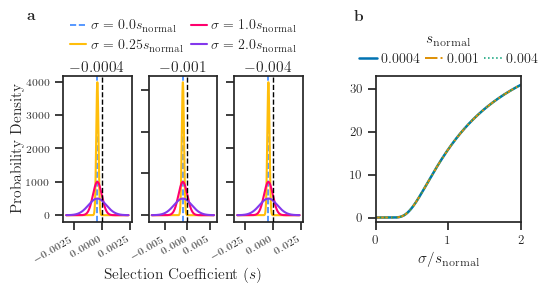

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm

# Theme & Context Setup
sns.set_context("paper")
sns.set_theme(style="ticks")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
})

cb_palette = ["#3A86FF", "#FFBE0B", "#FF006E", "#8338EC", "#FB5607"]

# 1. ADJUST ASPECT RATIO
fig_width = 426.79134 / 72.27  # ~5.905 inches (standard single/two-column width)
fig_height = fig_width / 2.15  # Slightly lower height prevents vertically stretched canvases

fig = plt.figure(figsize=(fig_width, fig_height))

# GridSpec layout: Top tags, middle legends, bottom plot canvases
gs_outer = gridspec.GridSpec(
    3, 2, 
    figure=fig, 
    height_ratios=[0.08, 0.16, 1.0], 
    width_ratios=[1.65, 1.0], 
    wspace=0.38, 
    hspace=0.25
)

# --- PANEL LABELS ('a' and 'b') ---
ax_tag_a = fig.add_subplot(gs_outer[0, 0])
ax_tag_a.axis('off')
ax_tag_a.text(-0.15, 0.5, r"\textbf{a}", transform=ax_tag_a.transAxes, fontsize=11, fontweight='bold', va='center', ha='left')

ax_tag_b = fig.add_subplot(gs_outer[0, 1])
ax_tag_b.axis('off')
ax_tag_b.text(-0.15, 0.5, r"\textbf{b}", transform=ax_tag_b.transAxes, fontsize=11, fontweight='bold', va='center', ha='left')

# --- PANEL A (Left 3 Subplots) ---
# 2. PREVENT TITLE OVERLAP: set wspace=0.25–0.30 between individual subplots
gs_a = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[2, 0], wspace=0.25)
axes_a = [fig.add_subplot(gs_a[0, i]) for i in range(3)]

means = [-0.0004, -0.001, -0.004]
sd_multipliers = [0.0, 0.25, 1.0, 2.0]

for i, mean in enumerate(means):
    ax = axes_a[i]
    abs_mean = abs(mean)
    max_sd = max(sd_multipliers) * abs_mean
    x = np.linspace(mean - 3.5 * max_sd, mean + 3.5 * max_sd, 500)
    
    for j, multiplier in enumerate(sd_multipliers):
        sd = multiplier * abs_mean
        label = fr"$\sigma = {multiplier} s_{{\mathrm{{normal}}}}$"
        if sd == 0:
            ax.axvline(x=mean, color=cb_palette[j], linestyle="--", linewidth=1.2, label=label)
        else:
            y = norm.pdf(x, mean, sd)
            ax.plot(x, y, color=cb_palette[j], linewidth=1.5, label=label)
            
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.0, zorder=3)
    
    # Clean sub-titles with minimal padding
    ax.set_title(fr"${mean}$", fontsize=11, pad=3)
    ax.tick_params(axis='both', which='major', labelsize=7.5)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    
    if i == 0:
        ax.set_ylabel("Probability Density", fontsize=11, labelpad=2)
    else:
        ax.tick_params(axis='y', left=True, labelleft=False)

# Centered X-label for Panel A
axes_a[1].set_xlabel("Selection Coefficient ($s$)", fontsize=11, labelpad=4)

# Dedicated Top Legend Panel A
ax_leg_a = fig.add_subplot(gs_outer[1, 0])
ax_leg_a.axis('off')
handles_a, labels_a = axes_a[0].get_legend_handles_labels()
ax_leg_a.legend(
    handles_a, labels_a, 
    loc='center', 
    ncol=2, 
    fontsize=10, 
    frameon=False,
    columnspacing=0.6,
    handletextpad=0.3,
    handlelength=1.2,
    bbox_to_anchor=(0.5, 1.05)
)

# --- PANEL B (Right Main Plot) ---
ax_b = fig.add_subplot(gs_outer[2, 1])

selection_coefficients = [-0.0004, -0.001, -0.004]
ratios = np.linspace(0.0001, 2.0, 500)
linestyles = ['-', '-.', ':']
linewidths = [1.8, 1.4, 1.1]
palette_b = sns.color_palette("colorblind", 3)

for i, s in enumerate(selection_coefficients):
    sigma_values = ratios * abs(s)
    pct_beneficial = (1 - norm.cdf(0, loc=s, scale=sigma_values)) * 100
    ax_b.plot(
        ratios, 
        pct_beneficial, 
        label=fr'${abs(s)}$', 
        color=palette_b[i], 
        linestyle=linestyles[i],
        linewidth=linewidths[i]
    )

ax_b.set_xlabel(r'$\sigma / s_{\mathrm{normal}}$', fontsize=11, labelpad=4)
ax_b.set_ylabel(r'% Beneficial Mutations', fontsize=11, labelpad=2)
ax_b.tick_params(axis='both', which='major', labelsize=9.0)
ax_b.set_xlim(0, 2)
ax_b.set_ylim(-1, 33)

# Dedicated Top Legend Panel B
ax_leg_b = fig.add_subplot(gs_outer[1, 1])
ax_leg_b.axis('off')
handles_b, labels_b = ax_b.get_legend_handles_labels()
ax_leg_b.legend(
    handles_b, labels_b,
    loc='center',
    ncols=3,
    title=r'$s_{\mathrm{normal}}$',
    title_fontsize=11,
    frameon=False,
    fontsize=10,
    handlelength=1.3,
    columnspacing=0.4,
    handletextpad=0.3
)

plt.savefig("tmp/figures/selection_coefficient_distributions.jpg", dpi=600, bbox_inches="tight")
plt.show()